# 30 m Grid Floor + Transparent Cubes (empty.umap)

30 m グリッド床 + 透明箱（最大 10,000）+ Humanoid + SpotDog を Unreal にスポーンします。

ロジック本体は同ディレクトリの `grid_env_hri_simulation.py` です。この Notebook からはモジュールを import して段階実行します。

## 前提

1. **Windows**: `C:\SimWorldServer` で SimWorld を起動
   ```text
   .\SimWorld.exe -windowed -log /Game/Maps/empty.umap
   ```
2. **pakchunk9002** に `BP_Floor_30x30` / `BP_TransparentCube` が含まれていること
3. **WSL**: `conda activate simworld` のカーネルで実行

## 座標系（UE cm、empty マップ）

- 床 30 m 四方の **左下隅** が `(x, y) = (0, 0)`
- 床上面の高さ = **100 cm**（empty 原点から 1 m）
- Human / Robot のマップ座標 [m] は material_transport の grid_map と同じ比率（既定: human `(1,1)`, robot `(1,3)`）
- Humanoid / Robot は **床面上に直接配置**（Simulated Physics は既定 OFF。ON にするとラグドール化します）
- **透明箱（格子）**: 床 **左下角** `(0,0)` から `GRID_N×0.3 m` の領域に `BP_TransparentCube`。既定はほぼ非表示 → `SetBlocking` + 薄い色付け。カメラが Humanoid 付近だと **画面に写らない** ことが多い
- **デモ用 TransparentCube（pakchunk9002）**: L 字 3 個は **当たりあり**（`SetBlocking True`、見た目は半透明グレーのまま）、`(5.5,5.5)` 1 個は **通過可**（`SetBlocking False`）。SpotDog を L 字側へ動かすと当たり差を確認しやすい

## 実行順

1. 初期設定 → 2. UE 接続ヘルパ → 3. UE 接続 → 4. 設定（`reload(geh)`）→ 5. レイアウト図 → 6. 床 → 7. 透明格子箱 → **8. デモ用 TransparentCube（実体/半透明）** → 9. エージェント → 10. 落下待ち → 11. クリーンアップ  
小規模テストは **設定** セルで `GRID_N = 3`（9 箱）にしてからスポーンしてください。

接続は `grid_env_hri_simulation.ensure_connection()` を使います。各候補 IP を **数秒の TCP プローブ**で確認してから接続するため、到達不能な `10.103.0.1` で数分ハングしません。WSL で `127.0.0.1:9000` が **python** のときはスキップ（`malformat magic 255` 防止）。SimWorld 起動後に **設定セルで `importlib.reload(geh)`** してから UE 接続してください。

In [1]:
import importlib
import os
import sys
import time
from pathlib import Path
from typing import Optional, Tuple


def _find_project_root() -> Path:
    search_starts = []
    if "__file__" in globals():
        search_starts.append(Path(__file__).resolve().parent)
    search_starts.append(Path.cwd().resolve())

    for start in search_starts:
        for candidate in (start, *start.parents):
            if (candidate / "setup.py").exists() and (candidate / "simworld").is_dir():
                return candidate

    return Path.cwd().resolve().parent.parent


_root = _find_project_root()
_geh_dir = _root / "dev" / "grid_env_hri"
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
if str(_geh_dir) not in sys.path:
    sys.path.insert(0, str(_geh_dir))

from simworld.communicator.communicator import Communicator
from simworld.communicator.unrealcv import UnrealCV

ucv: Optional[UnrealCV] = None
communicator: Optional[Communicator] = None
UE_PORT = 9000

print(f"[Paths] root={_root}")
print(f"[Paths] grid_env_hri={_geh_dir}")

[Paths] root=/home/winder17wsl_ishizawalab/00_kotaprivate/Program/SimWorld
[Paths] grid_env_hri=/home/winder17wsl_ishizawalab/00_kotaprivate/Program/SimWorld/dev/grid_env_hri


In [2]:
import grid_env_hri_simulation as geh


def ensure_connection() -> Tuple[UnrealCV, Communicator]:
    """既存接続を再利用しつつ、接続ロジックは grid_env_hri_simulation.py に委譲。"""
    global ucv, communicator

    if ucv is not None and ucv.client.isconnected():
        if communicator is None or communicator.unrealcv is not ucv:
            communicator = Communicator(ucv)
        return ucv, communicator

    if ucv is not None:
        try:
            ucv.disconnect()
        except Exception:
            pass
        ucv = None
        communicator = None

    ucv, communicator = geh.ensure_connection()
    return ucv, communicator

In [3]:
ucv, communicator = ensure_connection()

[UE] Probing UnrealCV on ['127.0.0.1', '10.103.0.1', '10.255.255.254'] (timeout=3s each) ...
[UE] probe OK: 127.0.0.1:9000


INFO:__init__:238:Got connection confirm: b'connected to SimWorld'


[UE] probe skip: 10.103.0.1:9000
[UE] probe skip: 10.255.255.254:9000
=>Info: using ip-port socket
[UE] Connected via UnrealCV at 127.0.0.1:9000


In [4]:
# ---- 実行パラメータ（Notebook 既定は小規模テスト） ----
GRID_N = 3  # 本番 10,000 箱: 100
SPAWN_INTERVAL_S = 0.005
CUBE_ENABLE_PHYSICS = True
CUBE_SPAWN_ABOVE_FLOOR_CM = 5.0  # 大きいと角の箱が床外へ弾ける
AGENT_ENABLE_PHYSICS = False  # True でも Humanoid/Robot では無視（ラグドール防止）

os.environ["GRID_N"] = str(GRID_N)
os.environ["SPAWN_INTERVAL_S"] = str(SPAWN_INTERVAL_S)
os.environ["CUBE_ENABLE_PHYSICS"] = "1" if CUBE_ENABLE_PHYSICS else "0"
os.environ["CUBE_SPAWN_ABOVE_FLOOR_CM"] = str(CUBE_SPAWN_ABOVE_FLOOR_CM)
os.environ["AGENT_ENABLE_PHYSICS"] = "1" if AGENT_ENABLE_PHYSICS else "0"

import grid_env_hri_simulation as geh

importlib.reload(geh)

cube_registry: dict = {}
human_name: Optional[str] = None
robot_ok: bool = False

print(
    f"[Config] GRID_N={geh.GRID_N} ({geh.GRID_N ** 2} cubes), "
    f"floor_top_z={geh.FLOOR_TOP_Z_CM} cm, origin={geh.MAP_ORIGIN_XY_CM}"
)
print(
    f"  human map={geh.HUMAN_MAP_XY_M} m, robot map={geh.ROBOT_MAP_XY_M} m, "
    f"cube_physics={geh.CUBE_ENABLE_PHYSICS}, cube_drop_cm={geh.CUBE_SPAWN_ABOVE_FLOOR_CM}, "
    f"human_z={geh.HUMAN_SPAWN_Z_CM}, robot_z={geh.ROBOT_SPAWN_Z_CM}"
)

[Config] GRID_N=3 (9 cubes), floor_top_z=100.0 cm, origin=(0.0, 0.0)
  human map=(1.0, 1.0) m, robot map=(1.0, 3.0) m, cube_physics=True, cube_drop_cm=5.0, human_z=100.0, robot_z=100.0


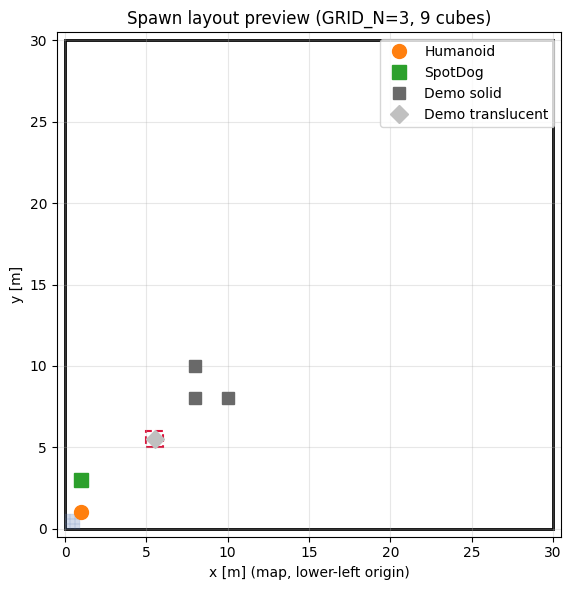

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(6, 6))
floor_m = geh.FLOOR_SIZE_M
ax.add_patch(
    mpatches.Rectangle((0, 0), floor_m, floor_m, fill=False, edgecolor="black", linewidth=2)
)

n = geh.GRID_N
cube_m = geh.CUBE_SIZE_M
for row in range(n):
    for col in range(n):
        ax.add_patch(
            mpatches.Rectangle(
                (col * cube_m, row * cube_m),
                cube_m,
                cube_m,
                facecolor="#4c72b0",
                alpha=0.25,
                edgecolor="#4c72b0",
                linewidth=0.3,
            )
        )

hx, hy = geh.HUMAN_MAP_XY_M
rx, ry = geh.ROBOT_MAP_XY_M
ax.plot(hx, hy, "o", color="tab:orange", markersize=10, label="Humanoid")
ax.plot(rx, ry, "s", color="tab:green", markersize=10, label="SpotDog")

for idx, (mx, my) in enumerate(geh.DEMO_SOLID_MAP_XY_M):
    ax.plot(mx, my, "s", color="dimgray", markersize=8, label="Demo solid" if idx == 0 else None)
for idx, (mx, my) in enumerate(geh.DEMO_TRANSLUCENT_MAP_XY_M):
    ax.plot(mx, my, "D", color="silver", markersize=9, label="Demo translucent" if idx == 0 else None)
    ax.add_patch(
        mpatches.Rectangle(
            (mx - 0.5, my - 0.5),
            1.0,
            1.0,
            fill=False,
            edgecolor="crimson",
            linewidth=1.5,
            linestyle="--",
        )
    )

ax.set_xlim(-0.5, floor_m + 0.5)
ax.set_ylim(-0.5, floor_m + 0.5)
ax.set_aspect("equal")
ax.set_xlabel("x [m] (map, lower-left origin)")
ax.set_ylabel("y [m]")
ax.set_title(f"Spawn layout preview (GRID_N={n}, {n * n} cubes)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
if not geh.spawn_fixed_floor(ucv):
    raise RuntimeError("[Floor] spawn failed — PAK / BP パス / SimWorld 再起動を確認")

[Floor] prepare UE (clean_garbage) ...
[Floor] remove stale actor if any ...
[Floor] spawn /Game/CustomAssets/BP_Floor_30x30.BP_Floor_30x30_C ...
[UE] spawn_bp_asset 'grid_floor_main' (timeout=180s) ...
[Floor] fixed at center=(1500.0, 1500.0, 100.0) (corner @ (0.0, 0.0), top Z≈100.0 cm)


In [7]:
cube_registry = geh.spawn_cubes(ucv, geh.GRID_N)
print(f"[Cubes] registry size: {len(cube_registry)}")

[Cubes] spawning 9 transparent grid cubes (GRID_N=3, physics=True)
  grid covers map x,y in [0, 0.9] m (floor corner); agents @ human (1.0, 1.0) m, robot (1.0, 3.0) m — camera near agents may not show the grid
[UE] spawn_bp_asset 'cube_000_000' (timeout=180s) ...
[UE] spawn_bp_asset 'cube_000_001' (timeout=180s) ...
[UE] spawn_bp_asset 'cube_000_002' (timeout=180s) ...
[UE] spawn_bp_asset 'cube_001_000' (timeout=180s) ...
[UE] spawn_bp_asset 'cube_001_001' (timeout=180s) ...
[UE] spawn_bp_asset 'cube_001_002' (timeout=180s) ...
[UE] spawn_bp_asset 'cube_002_000' (timeout=180s) ...
[UE] spawn_bp_asset 'cube_002_001' (timeout=180s) ...
[UE] spawn_bp_asset 'cube_002_002' (timeout=180s) ...
  row 3/3 (9/9)
[Cubes] done: 9
[Cubes] registry size: 9


In [8]:
marker_registry: dict = {}
if geh.SPAWN_DEMO_MODE_CUBES:
    marker_registry = geh.spawn_demo_mode_cubes(ucv)
print(f"[DemoCubes] registry size: {len(marker_registry)}")

[DemoCubes] solid(SetBlocking True) @ [(8.0, 8.0), (10.0, 8.0), (8.0, 10.0)] m, translucent(False) @ [(5.5, 5.5)] m (BP=/Game/CustomAssets/BP_TransparentCube.BP_TransparentCube_C)
[UE] spawn_bp_asset 'demo_solid_00' (timeout=180s) ...
  demo_solid_00 solid map=(8.0, 8.0) m → (800.0, 800.0, 117.0)
[UE] spawn_bp_asset 'demo_solid_01' (timeout=180s) ...
  demo_solid_01 solid map=(10.0, 8.0) m → (1000.0, 800.0, 117.0)
[UE] spawn_bp_asset 'demo_solid_02' (timeout=180s) ...
  demo_solid_02 solid map=(8.0, 10.0) m → (800.0, 1000.0, 117.0)
[UE] spawn_bp_asset 'demo_translucent_00' (timeout=180s) ...
  demo_translucent_00 translucent map=(5.5, 5.5) m → (550.0, 550.0, 117.0) (SetBlocking False — BP の半透明グレー表示)
[DemoCubes] done: 4
[DemoCubes] registry size: 4


In [9]:
human_name = geh.spawn_humanoid(communicator, ucv)
robot_ok = geh.spawn_robot(ucv)
print(f"[Agents] humanoid={human_name}, robot_ok={robot_ok}")

(100.0, 100.0, 100.0)
[Humanoid] GEN_BP_Humanoid_0 spawn @ (100.0, 100.0, 100.0) (kinematic, no sim physics)
[UE] spawn_bp_asset 'GridEnv_SpotRobot' (timeout=180s) ...
[Robot] GridEnv_SpotRobot @ (100.0, 300.0, 100.0) (controller on, no sim physics)
[Agents] humanoid=GEN_BP_Humanoid_0, robot_ok=True


In [10]:
if geh.SETTLE_AFTER_SPAWN_S > 0:
    print(f"[Settle] waiting {geh.SETTLE_AFTER_SPAWN_S}s for physics ...")
    time.sleep(geh.SETTLE_AFTER_SPAWN_S)

geh.report_spawn_state(
    ucv, cube_registry, human_name, marker_registry=marker_registry or None
)

print("[Done]")
print(f"  floor: {geh.FLOOR_ACTOR_NAME}")
print(f"  cubes: {len(cube_registry)}")
print(f"  humanoid: {human_name}")
print(f"  robot: {geh.ROBOT_ACTOR_NAME if robot_ok else 'FAILED'}")

[Settle] waiting 6.0s for physics ...
[Verify] actor locations after settle:
  floor grid_floor_main: (1500.0, 1500.0, 100.0)
  humanoid GEN_BP_Humanoid_0: (100.0, 100.0, 192.3) OK
  robot GridEnv_SpotRobot: (100.0, 300.0, 152.3) OK
  cubes: on/above floor=9, below floor z=0, missing=0, total=9
    sample cube_000_000: (15.0, 15.0, 120.0)
    sample cube_000_001: (45.0, 15.0, 120.0)
    sample cube_000_002: (75.0, 15.0, 120.0)
  demo_cubes: 4
    demo_solid_00 solid map=(8.0, 8.0) → (800.0, 800.0, 117.0)
    demo_solid_01 solid map=(10.0, 8.0) → (1000.0, 800.0, 117.0)
    demo_solid_02 solid map=(8.0, 10.0) → (800.0, 1000.0, 117.0)
    demo_translucent_00 translucent map=(5.5, 5.5) → (550.0, 550.0, 117.0)
[Done]
  floor: grid_floor_main
  cubes: 9
  humanoid: GEN_BP_Humanoid_0
  robot: GridEnv_SpotRobot


## クリーンアップ（任意）

スポーンした床・箱・ロボットを Unreal から削除します。Humanoid は Communicator 経由のため、必要に応じて UE 側で手動削除してください。

In [11]:
# RUN_CLEANUP = True にしてから実行
RUN_CLEANUP = False

if RUN_CLEANUP:
    geh.cleanup_spawned(
        ucv,
        cube_registry.keys(),
        marker_ids=marker_registry.keys(),
    )
    if human_name:
        geh.destroy_if_exists(ucv, human_name)
    print("[Cleanup] floor, transparent cubes, demo cubes, robot destroyed.")
else:
    print("[Cleanup] skipped (set RUN_CLEANUP = True to destroy spawned actors)")

[Cleanup] skipped (set RUN_CLEANUP = True to destroy spawned actors)
